In [4]:
# =========================
# 1. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import joblib

In [5]:
import pandas as pd

df = pd.read_csv("../data/insurance_claim_dataset.csv")
df.head()

,age,gender,annual_income,vehicle_type,driving_experience,previous_claims,claim_status,premium_amount,claim_amount
0,56,Male,55648,Car,10,3,0,2402,0
1,69,Male,135991,Bike,12,1,0,4246,0
2,46,Male,150588,Car,9,1,1,4049,32336
3,32,Female,125005,Bike,13,2,1,3501,37977
4,60,Male,12396,Car,17,1,1,1630,37775


In [6]:
# =========================
# 3. BASIC PREPROCESSING
# =========================

# Encode categorical variables
le_gender = LabelEncoder()
le_vehicle = LabelEncoder()

df["gender"] = le_gender.fit_transform(df["gender"]) # type: ignore
df["vehicle_type"] = le_vehicle.fit_transform(df["vehicle_type"]) # type: ignore

df.head() # type: ignore

,age,gender,annual_income,vehicle_type,driving_experience,previous_claims,claim_status,premium_amount,claim_amount
0,56,1,55648,1,10,3,0,2402,0
1,69,1,135991,0,12,1,0,4246,0
2,46,1,150588,1,9,1,1,4049,32336
3,32,0,125005,0,13,2,1,3501,37977
4,60,1,12396,1,17,1,1,1630,37775


In [7]:
# =========================
# 3. BASIC CLEANING
# =========================

# Check missing values
print(df.isnull().sum())

# Fill missing numeric values (safe default)
df = df.fillna(df.median(numeric_only=True))

age                   0
gender                0
annual_income         0
vehicle_type          0
driving_experience    0
previous_claims       0
claim_status          0
premium_amount        0
claim_amount          0
dtype: int64


In [8]:
# =========================
# 4. ENCODING CATEGORICAL VARIABLES
# =========================

le_gender = LabelEncoder()
le_vehicle = LabelEncoder()

df["gender"] = le_gender.fit_transform(df["gender"])
df["vehicle_type"] = le_vehicle.fit_transform(df["vehicle_type"])

In [9]:
# =========================
# 5. FEATURE ENGINEERING (VERY IMPORTANT)
# =========================

# Young driver risk
df["risk_flag_young"] = (df["age"] < 25).astype(int)

# New driver risk
df["risk_flag_new_driver"] = (df["driving_experience"] < 3).astype(int)

# Claim history intensity
df["claim_ratio"] = df["previous_claims"] / (df["age"] + 1)

# Income risk balance (ability to pay premium)
df["income_premium_ratio"] = df["annual_income"] / (df["premium_amount"] + 1)

In [10]:
# =========================
# 6. FINAL CHECK
# =========================

df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   1000 non-null   int64  
 1   gender                1000 non-null   int64  
 2   annual_income         1000 non-null   int64  
 3   vehicle_type          1000 non-null   int64  
 4   driving_experience    1000 non-null   int64  
 5   previous_claims       1000 non-null   int64  
 6   claim_status          1000 non-null   int64  
 7   premium_amount        1000 non-null   int64  
 8   claim_amount          1000 non-null   int64  
 9   risk_flag_young       1000 non-null   int64  
 10  risk_flag_new_driver  1000 non-null   int64  
 11  claim_ratio           1000 non-null   float64
 12  income_premium_ratio  1000 non-null   float64
dtypes: float64(2), int64(11)
memory usage: 101.7 KB


In [11]:
# Drop target + leakage column
X = df.drop(["claim_status", "claim_amount"], axis=1)
y = df["claim_status"]

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [14]:
y_pred = model.predict(X_test)

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.7

Confusion Matrix:
 [[ 14  43]
 [ 17 126]]

Classification Report:
               precision    recall  f1-score   support

           0       0.45      0.25      0.32        57
           1       0.75      0.88      0.81       143

    accuracy                           0.70       200
   macro avg       0.60      0.56      0.56       200
weighted avg       0.66      0.70      0.67       200



In [16]:
import pandas as pd
import matplotlib.pyplot as plt


importances = model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(importance_df)

                 feature  importance
2          annual_income    0.163248
6         premium_amount    0.159937
10  income_premium_ratio    0.156337
9            claim_ratio    0.144449
4     driving_experience    0.135177
0                    age    0.124379
5        previous_claims    0.055466
3           vehicle_type    0.024104
1                 gender    0.022248
7        risk_flag_young    0.007402
8   risk_flag_new_driver    0.007252


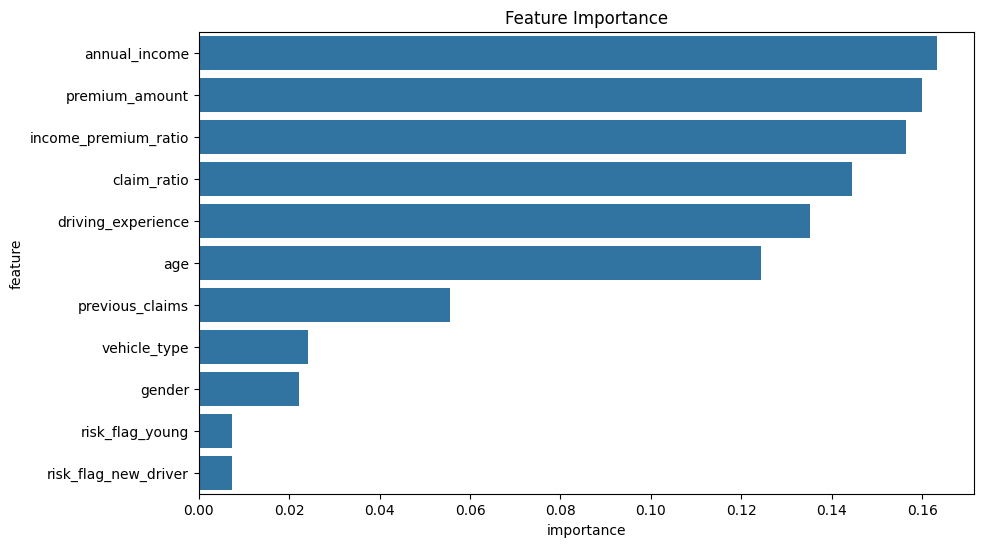

In [17]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x="importance", y="feature", data=importance_df)
plt.title("Feature Importance")
plt.show()

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}


In [19]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test)

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_best))

              precision    recall  f1-score   support

           0       0.37      0.12      0.18        57
           1       0.72      0.92      0.81       143

    accuracy                           0.69       200
   macro avg       0.55      0.52      0.50       200
weighted avg       0.62      0.69      0.63       200



In [21]:
train_score = best_model.score(X_train, y_train)
test_score = best_model.score(X_test, y_test)

print("Train Score:", train_score)
print("Test Score:", test_score)

Train Score: 0.90375
Test Score: 0.69


In [22]:
import joblib

joblib.dump(best_model, "../models/best_insurance_model.pkl")
joblib.dump(le_gender, "../models/label_gender.pkl")
joblib.dump(le_vehicle, "../models/label_vehicle.pkl")

['../models/label_vehicle.pkl']